```
==============================
 ___  ___ _____ _   _ ___
/ __|/ __|_   _| | | | _ \
\__ \ (__  | | | |_| |  _/
|___/\___| |_|  \___/|_|
==============================
```

In [18]:
# pip install clickhouse-driver wordcloud matplotlib numpy
from clickhouse_driver import Client
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from wordcloud import WordCloud

In [19]:
# Catppuccin Mocha palette
CATPPUCCIN_MOCHA = [
    "#f5e0dc",  # Rosewater
    "#f2cdcd",  # Flamingo
    "#f5c2e7",  # Pink
    "#cba6f7",  # Mauve
    "#f38ba8",  # Red
    "#eba0ac",  # Maroon
    "#fab387",  # Peach
    "#f9e2af",  # Yellow
    "#a6e3a1",  # Green
    "#94e2d5",  # Teal
    "#89dceb",  # Sky
    "#74c7ec",  # Sapphire
    "#89b4fa",  # Blue
    "#b4befe",  # Lavender
]
CATPPUCCIN_BASE = "#1e1e2e"   # Mocha base (background)

catppuccin_cmap = mcolors.LinearSegmentedColormap.from_list(
    "catppuccin_mocha", CATPPUCCIN_MOCHA
)

def catppuccin_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    color = CATPPUCCIN_MOCHA[random_state.randint(0, len(CATPPUCCIN_MOCHA) - 1)]
    return color

```
================================================
__    __  ___  ___  ___      ___  _     ___  _   _ ___ 
\ \  / / / _ \| _ \|   \    / __|| |   / _ \| | | |   \
 \ \/ / | (_) |   /| |) |  | (__ | |__| (_) | |_| | |) |
  \__/   \___/|_|_\|___/    \___||____|\___/ \___/ |___/
================================================
```

In [20]:
# Query top 200 words from the gold model
client = Client(
    host="localhost",
    port=9100,
    user="clickhouse",
    password="clickhouse",
    database="analytics",
)

rows = client.execute(
    """
    SELECT word, word_count
    FROM analytics.gold_game_title_word_cloud
    ORDER BY word_count DESC
    LIMIT 200
    """
)

word_freq = {word: count for word, count in rows}

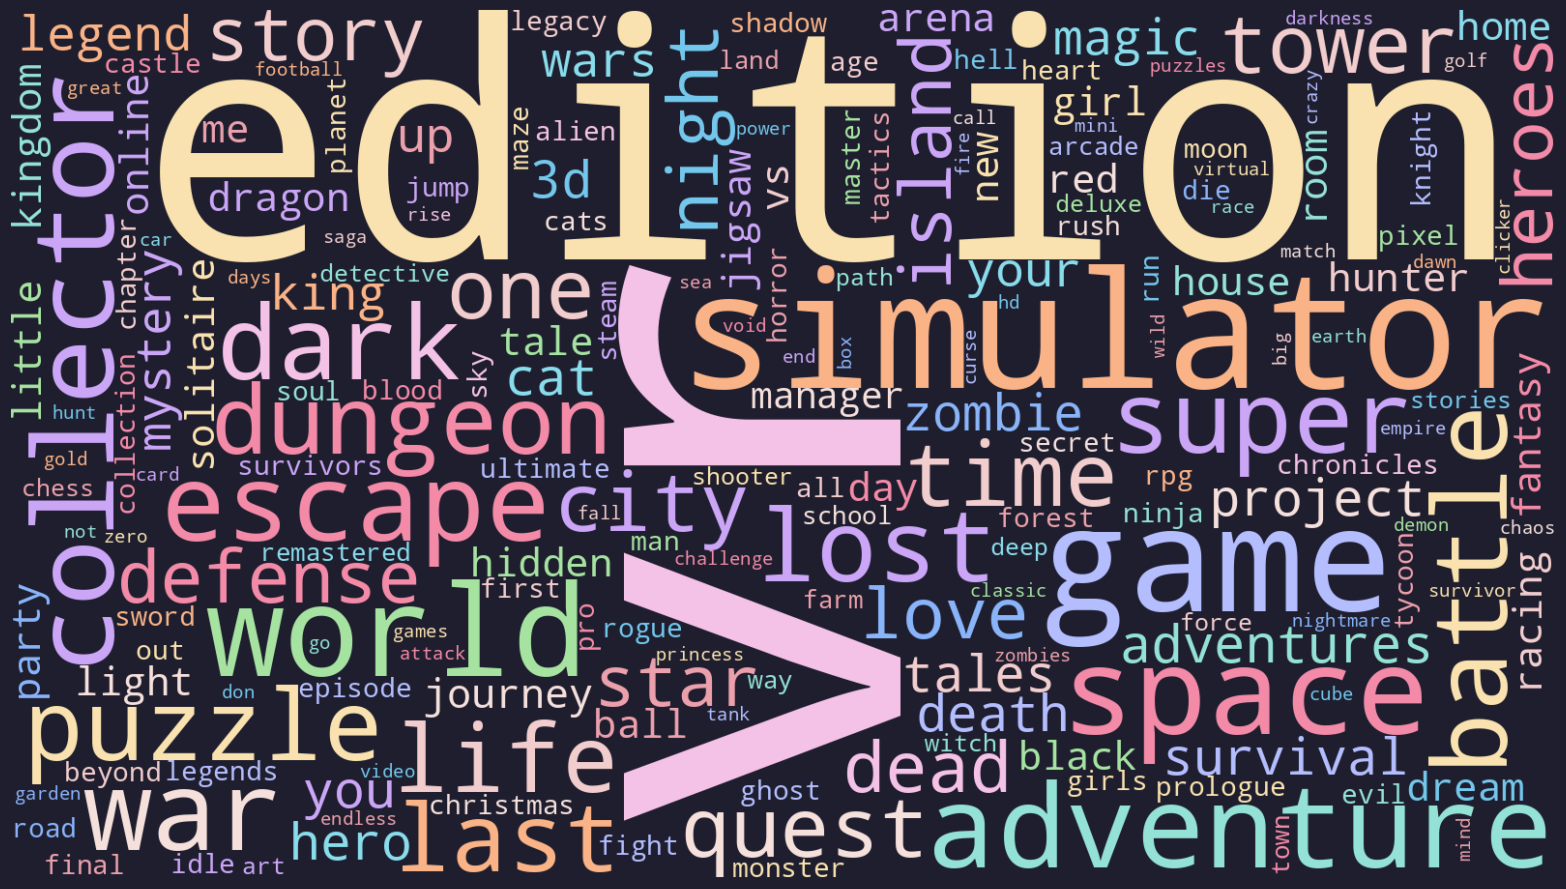

In [21]:
wc = WordCloud(
    width=1600,
    height=900,
    background_color=CATPPUCCIN_BASE,
    color_func=catppuccin_color_func,
    max_words=200,
    prefer_horizontal=0.8,
    relative_scaling=0.5,
).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(16, 9), facecolor=CATPPUCCIN_BASE)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

plt.tight_layout()
plt.savefig("word_cloud.png", dpi=150, bbox_inches="tight", facecolor=CATPPUCCIN_BASE)
plt.show()

```
================================================
 _____ ___  ___     ___  ___     ___   _   __  __ ___ ___
|_   _/ _ \| _ \   | __||_ _|  / __| /_\ |  \/  | __/ __|
  | || (_) |  _/   | _|  | |  | (_ |/ _ \| |\/| | _|\__ \
  |_| \___/|_|     |_|  |___|  \___/_/ \_\_|  |_|___|___/
================================================
```

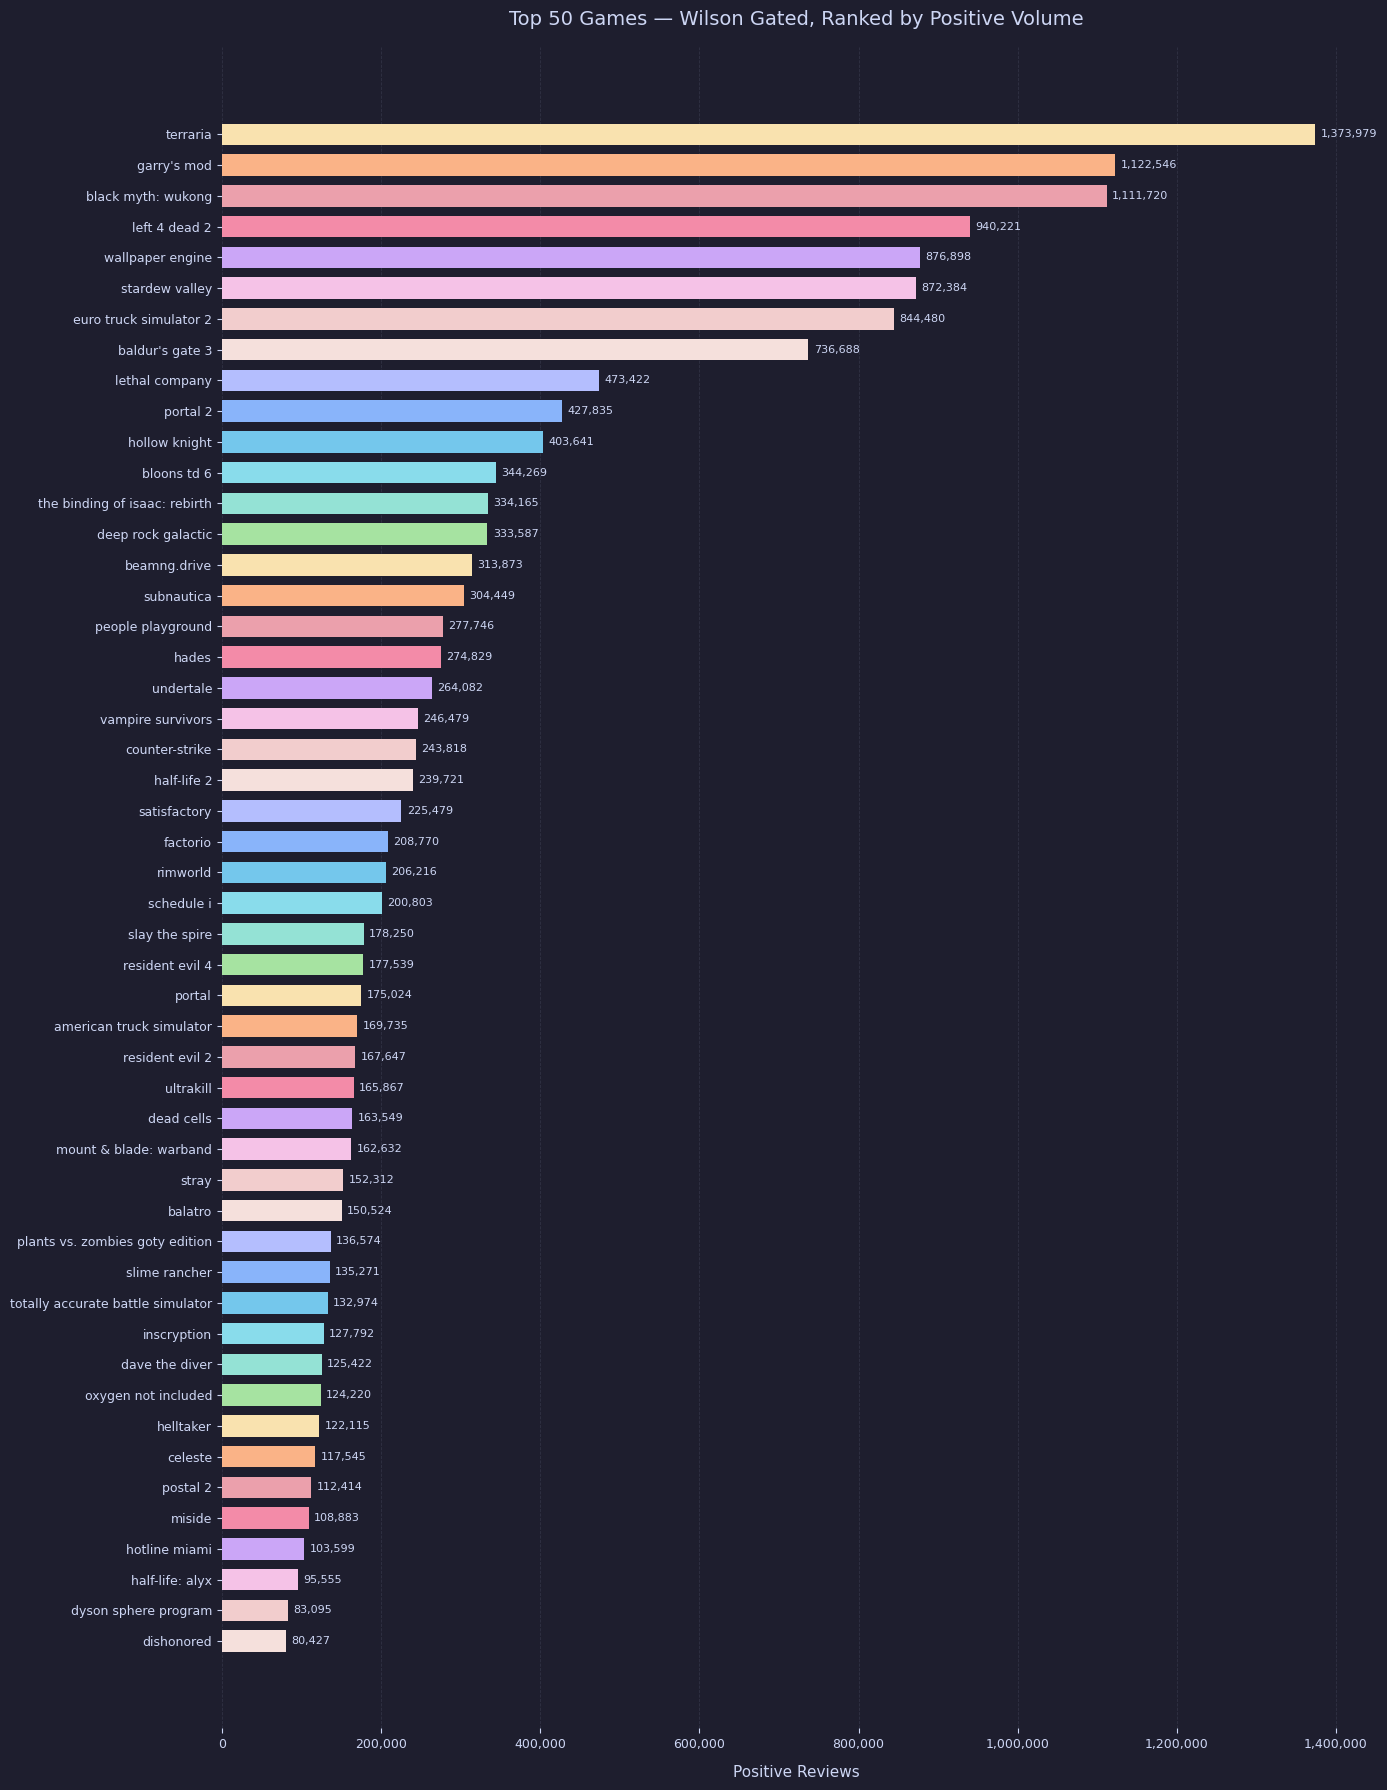

In [22]:
rows = client.execute(
    """
    SELECT game_title, positive, approval_pct, wilson_score
    FROM analytics.gold_top_games_ranked
    ORDER BY rank ASC
    LIMIT 50
    """
)

# Reverse so rank 1 appears at the top
games = [r[0] for r in rows][::-1]
positive_reviews = [r[1] for r in rows][::-1]

bar_colors = [CATPPUCCIN_MOCHA[i % len(CATPPUCCIN_MOCHA)] for i in range(len(games))]

fig, ax = plt.subplots(figsize=(14, 18), facecolor=CATPPUCCIN_BASE)
fig.patch.set_facecolor(CATPPUCCIN_BASE)
ax.set_facecolor(CATPPUCCIN_BASE)

bars = ax.barh(games, positive_reviews, color=bar_colors, height=0.7, edgecolor="none")

for bar, val in zip(bars, positive_reviews):
    ax.text(
        bar.get_width() + max(positive_reviews) * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        ha="left",
        color="#cdd6f4",
        fontsize=8,
    )

ax.set_xlabel("Positive Reviews", color="#cdd6f4", labelpad=10, fontsize=11)
ax.set_title("Top 50 Games — Wilson Gated, Ranked by Positive Volume", color="#cdd6f4", fontsize=14, pad=16)

ax.tick_params(axis="x", colors="#cdd6f4", labelsize=9)
ax.tick_params(axis="y", colors="#cdd6f4", labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(True, color="#313244", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("top_50_games_hybrid.png", dpi=150, bbox_inches="tight", facecolor=CATPPUCCIN_BASE)
plt.show()

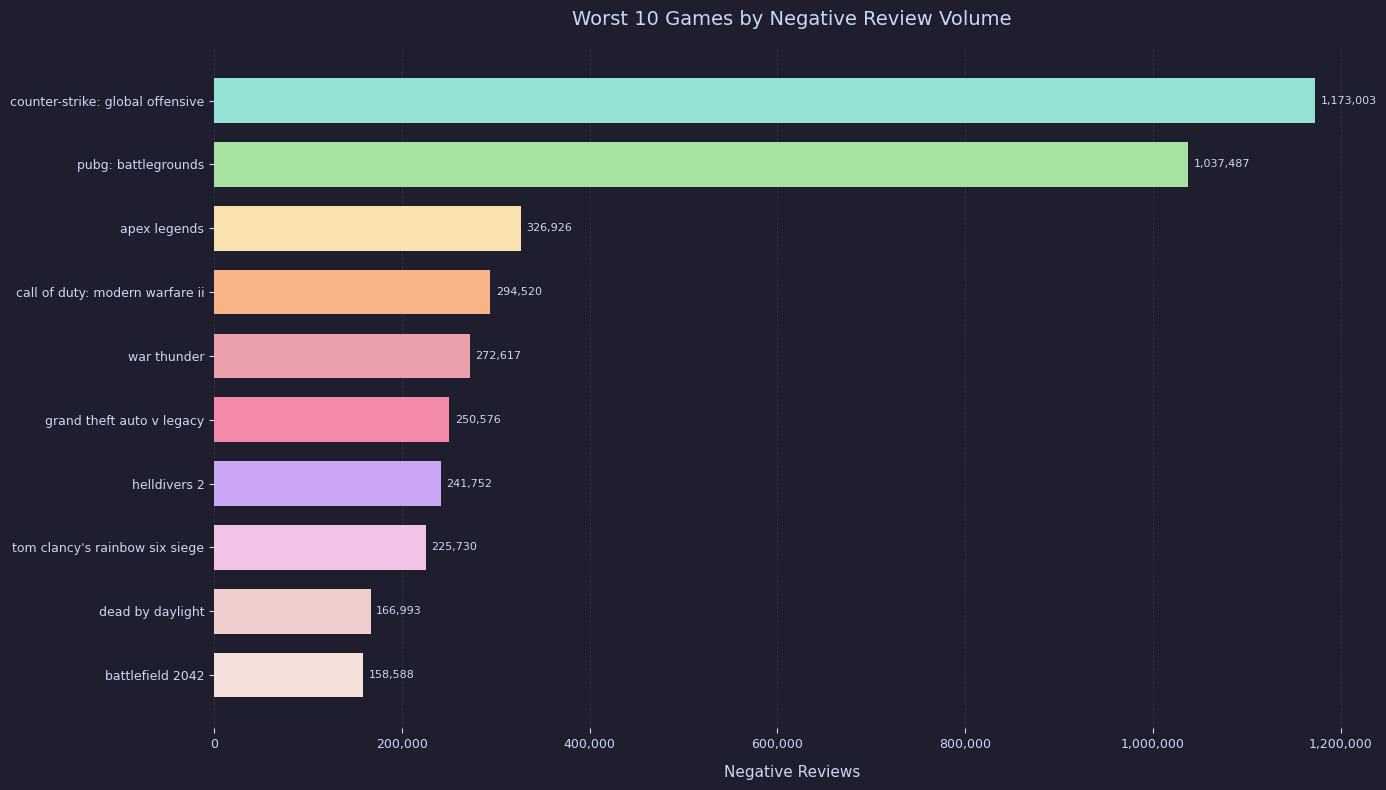

In [23]:
rows = client.execute(
    """
    SELECT game_title, negative
    FROM analytics.gold_worst_games_ranked
    ORDER BY rank ASC
    LIMIT 10
    """
)

# Reverse so rank 1 appears at the top
games = [r[0] for r in rows][::-1]
negative_reviews = [r[1] for r in rows][::-1]

bar_colors = [CATPPUCCIN_MOCHA[i % len(CATPPUCCIN_MOCHA)] for i in range(len(games))]

fig, ax = plt.subplots(figsize=(14, 8), facecolor=CATPPUCCIN_BASE)
fig.patch.set_facecolor(CATPPUCCIN_BASE)
ax.set_facecolor(CATPPUCCIN_BASE)

bars = ax.barh(games, negative_reviews, color=bar_colors, height=0.7, edgecolor="none")

for bar, val in zip(bars, negative_reviews):
    ax.text(
        bar.get_width() + max(negative_reviews) * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        ha="left",
        color="#cdd6f4",
        fontsize=8,
    )

ax.set_xlabel("Negative Reviews", color="#cdd6f4", labelpad=10, fontsize=11)
ax.set_title("Worst 10 Games by Negative Review Volume", color="#cdd6f4", fontsize=14, pad=16)

ax.tick_params(axis="x", colors="#cdd6f4", labelsize=9)
ax.tick_params(axis="y", colors="#cdd6f4", labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(True, color="#313244", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("worst_10_games.png", dpi=150, bbox_inches="tight", facecolor=CATPPUCCIN_BASE)
plt.show()